# Volumetric Ergodic Control Tutorial: MPC Erasing Point Cloud

2D MPC erasing task with double-integrator dynamics where the target is a point-cloud distribution and the volumetric state is a 2-D tool controlled from a pivot point.

In [1]:
# Imports and device setup

from functools import partial
import urllib.request

import imageio.v2 as imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display
from jax import grad, jit, vmap
from tqdm.auto import tqdm

try:
    from lqrax import iLQR
except ImportError:
    %pip install lqrax
    from lqrax import iLQR

jnp.set_printoptions(precision=4, suppress=True)

# Check if GPU is available, otherwise use CPU
try:
    device = jax.devices("gpu")[0]
except RuntimeError:
    device = jax.devices("cpu")[0]
print("Using device:", device)

Using device: cuda:0


### Choose the Target and Tool

Modify `target_name` and `agent_name` to run different erasing tasks.  
The target defines the shape to be erased, while the agent specifies the tool geometry used as the volumetric state.

In [2]:
# Available shapes: ["airplane", "eifeltower", "fire", "heart", "lock", "scissors", "star", "sword", "thunder", "trophy"]
agent_name = "sword"
target_name = "lock"

_x0 = jnp.array([0.3, 0.3])

In [3]:
# Load point clouds for the target and tool
target_resp = urllib.request.urlopen(f"https://raw.githubusercontent.com/MurpheyLab/vec/refs/heads/main/tutorials/2d_target/{target_name}.txt")
target_data = np.loadtxt(target_resp)[:, :2]

agent_resp = urllib.request.urlopen(f"https://raw.githubusercontent.com/MurpheyLab/vec/refs/heads/main/tutorials/2d_agent/{agent_name}.txt")
agent_data = np.loadtxt(agent_resp)[:, :2]

In [4]:
# Set parameters
dt = 0.05
tsteps = 50
T = dt * tsteps

# Use the centroid as the tool pivot for this tutorial
agent_xy = jnp.asarray(agent_data[:, :2])
agent_pivot_xy = jnp.mean(agent_xy, axis=0)
rel_pos = agent_xy - agent_pivot_xy

In [5]:
# Define the agent dynamics
class PointAgent(iLQR):
    def __init__(self, dt, x_dim, u_dim, Q, R):
        super().__init__(dt, x_dim, u_dim, Q, R)

    def dyn(self, xt, ut):
        """
        Double-integrator dynamics in (x, y, theta).
        
        State: xt = [x, y, theta, xdot, ydot, thetadot]
        Control: ut = [ax, ay, alpha]
        Returns: xdot = [xdot, ydot, thetadot, ax, ay, alpha]
        """
        x, y, theta, xdot, ydot, thetadot = xt
        ax, ay, alpha = ut
        return jnp.array([xdot, ydot, thetadot, ax, ay, alpha])

Q = jnp.diag(jnp.array([0.1, 0.1, 0.001, 0.001, 0.001, 0.001]))
R = jnp.diag(jnp.array([0.01, 0.01, 0.01]))

point_ilqr = PointAgent(dt=dt, x_dim=6, u_dim=3, Q=Q, R=R)

linearize_dyn = jit(point_ilqr.linearize_dyn, device=device)
solve_ilqr = jit(point_ilqr.solve, device=device)

L_list = jnp.array([1.0, 1.0]) # boundaries for each dimension

### Target Fourier Coefficients

The ergodic metric compares Fourier coefficients of the target distribution and the trajectory distribution. Here, the target point cloud is treated as uniformly weighted samples.

In [6]:
# Configure the index vectors
numk = 20 # number of basis functions for each dimension
ks_1, ks_2 = jnp.meshgrid(jnp.arange(numk), jnp.arange(numk))
ks = jnp.array([ks_1.ravel(), ks_2.ravel()]).T

# Sobolev weights and normalization constants
lamks = (1.0 + jnp.linalg.norm(ks, axis=1)) ** (-3/2.0)
hks = jnp.sqrt(jnp.prod(jnp.where(ks == 0, L_list[None, :], 0.5 * L_list[None, :]), axis=1))

# Target distribution, represented by samples with uniform weights
target_pts = jnp.array(target_data[:, :2])
target_pts = jnp.clip(target_pts * L_list, jnp.array([0.0, 0.0]), L_list) # Scale to [0,1] and clip to be safe
target_w = jnp.ones(target_pts.shape[0], dtype=target_pts.dtype) / target_pts.shape[0] # Uniform weights

# Target Fourier coefficients
fk_target = jnp.prod(jnp.cos(jnp.pi * ks[None, :, :] * (target_pts[:, None, :] / L_list[None, None, :])),axis=-1,) / hks[None, :]
phiks = jnp.sum(fk_target * target_w[:, None], axis=0)

### Volumetric Ergodic Metric
VEC replaces point-based trajectory statistics with averages of the Fourier basis over the tool’s volumetric state.

In [7]:
@jit
def body_to_world(xt):
    """Transform tool samples from the body frame to the world frame."""
    x, y, theta, _, _, _ = xt
    c, s = jnp.cos(theta), jnp.sin(theta)
    R = jnp.array([[ c, -s],
                   [ s,  c]])

    pts_raw = rel_pos @ R.T + jnp.array([x, y])
    
    # Only in-bounds samples contribute to the volumetric average
    inside = (pts_raw[:, 0] >= 0.0) & (pts_raw[:, 0] <= L_list[0]) & \
            (pts_raw[:, 1] >= 0.0) & (pts_raw[:, 1] <= L_list[1] )
    w = inside.astype(jnp.float32)
    
    # Clipping avoids evaluating basis functions outside the search domain
    pts_clip = jnp.clip(pts_raw, jnp.array([0.0, 0.0]), L_list)
    return pts_raw, pts_clip, w

@jit
def covered_now(x):
    """Discrete task metric for which target samples are erased"""
    _, pts_clip, w = body_to_world(x) 
    dx = target_pts[:, None, 0] - pts_clip[None, :, 0]
    dy = target_pts[:, None, 1] - pts_clip[None, :, 1]
    d2 = dx*dx + dy*dy 

    cover_radius = 0.005
    r2 = cover_radius * cover_radius
    valid = (w > 0.5)[None, :] # broadcasts across targets
    hit = (d2 <= r2) & valid
    return jnp.any(hit, axis=1) 

@jit
def fks_x(x):
    """Standard point-based Fourier basis"""
    return jnp.prod(jnp.cos(jnp.pi * ks * x[:2] / L_list), axis=-1) / hks

@jit
def fks_x_footprint(x):
    """Volumetric Fourier basis"""
    _, pts_clip, w = body_to_world(x)
    fk_pts = vmap(fks_x)(pts_clip)
    w_sum = jnp.sum(w)
    avg = jnp.sum(fk_pts * w[:, None], axis=0) / (w_sum + 1e-8)
    return jnp.where(w_sum > 0.0, avg, jnp.zeros_like(avg))

def barr(x_traj):
    """Barrier function to penalize out-of-bounds samples in the trajectory"""
    def barr_xt(xt):
        upper_bnd = jnp.array([0.95, 0.95])
        lower_bnd = jnp.array([0.05, 0.05])
        penalty_high = jnp.maximum(xt[:2] - upper_bnd, 0.0)
        penalty_low = jnp.maximum(lower_bnd - xt[:2], 0.0)
        val = jnp.sum(jnp.square(penalty_high)) + jnp.sum(jnp.square(penalty_low))
        return val * 10.0
    barr_traj = jax.vmap(barr_xt)(x_traj)
    return jnp.sum(barr_traj) * dt

def fourier_metric(x_traj, fk_sum_prev, T1, T2):
    """
    Receding-horizon volumetric ergodic metric.
    
    The key difference for MPC is to take into account previous trajectory when
    evaluating the ergodic metric.
    
    Here x_traj is the future trajectory that is being evaluated,
    fk_sum_prev is the summation (not average) of Fourier coefficients from all the previous states
    T1 is the planning time horizon (which is usually fixed)
    T2 is the number of time steps of the previous trajectory (which increases over time)
    """
    # fk_traj = vmap(fks_x)(x_traj) # for point-based ergodic metric
    fk_traj = vmap(fks_x_footprint)(x_traj) # for volumetric ergodic metric
    
    cks = (jnp.sum(fk_traj, axis=0) + fk_sum_prev) / (T1 + T2)
    loss = jnp.sum(lamks * jnp.square(cks - phiks))
    return loss + barr(x_traj)

# Autodiff the derivative of the Fourier ergodic metric
d_fourier_traj = grad(fourier_metric)

fourier_metric = jit(fourier_metric, device=device)
d_fourier_traj = jit(d_fourier_traj, device=device)

### iLQR Optimization Step

Each MPC step optimizes a short control sequence. The first optimized control is executed, then the problem is solved again from the new state.

In [8]:
@partial(jit, device=device)
def line_search(x0, u_traj, v_traj, fk_sum_prev, T1, T2):
    step_sizes = jnp.power(2.0, jnp.linspace(-5.0, 3.0, 20))
    u_traj_batch = u_traj[None, :, :] + step_sizes[:, None, None] * v_traj[None, :, :]
    x_traj_batch = vmap(point_ilqr.traj_sim, in_axes=(None, 0))(x0, u_traj_batch)
    x_traj_batch = jax.device_put(x_traj_batch, device=device)
    costs = vmap(fourier_metric, in_axes=(0, None, None, None))(x_traj_batch, fk_sum_prev, T1, T2)
    return step_sizes[jnp.argmin(costs)]

def ilqr_iter(x0, u_traj, fk_sum_prev, T1, T2):
    x_traj, A_traj, B_traj = linearize_dyn(x0, u_traj)
    fourier_dx_traj = d_fourier_traj(x_traj, fk_sum_prev, T1, T2)
    b_traj = jnp.zeros_like(u_traj)
    v_traj, z_traj = solve_ilqr(A_traj, B_traj, fourier_dx_traj, b_traj)
    step_size = line_search(x0, u_traj, v_traj, fk_sum_prev, T1, T2)
    u_traj += step_size * v_traj
    return u_traj

@partial(jit, device=device)
def ilqr_opt(x0, init_u_traj, fk_sum_prev, T1, T2):
    num_iters = 30
    u_traj = init_u_traj
    for i in range(num_iters):
        u_traj = ilqr_iter(x0, u_traj, fk_sum_prev, T1, T2)
    x_traj = point_ilqr.traj_sim(x0, u_traj)
    return x_traj, u_traj

### Run MPC


In [9]:
# Initial conditions
x0 = jnp.array([_x0[0], _x0[1], 0.0, 0.0, 0.0, 0.0])  
u0 = jnp.array([0.0, 0.0, 0.0])
u_traj = jnp.tile(u0, (tsteps, 1))

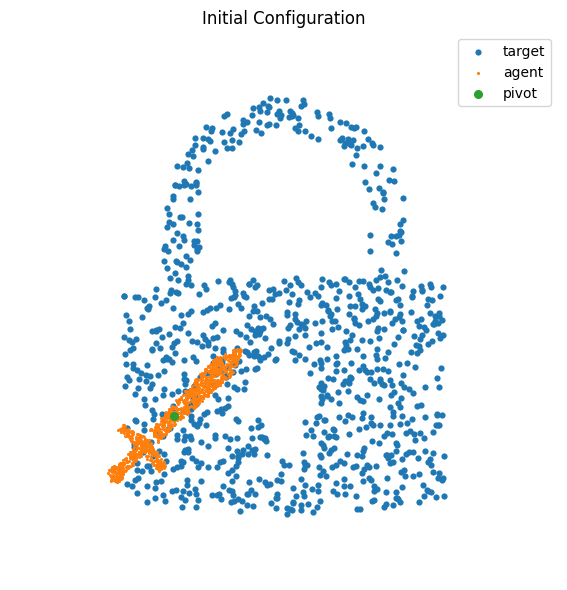

In [10]:
# Plot the starting configuration
_, footprint0, w0 = body_to_world(x0)
footprint0 = np.array(footprint0)
w0 = np.array(w0)
x0_np = np.array(x0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100, tight_layout=True)
ax.set_title("Initial Configuration")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.scatter(target_data[:, 0], target_data[:, 1], c='C0', label='target', s=20, alpha=1.0, linewidths=0)
ax.scatter(footprint0[w0 > 0.5, 0], footprint0[w0 > 0.5, 1], c='C1', label='agent', s=5, alpha=1.0, linewidths=0)
ax.scatter(x0_np[0], x0_np[1], c='C2', label='pivot', s=30)
ax.legend()
plt.show()
plt.close()

In [11]:
erg_log, coverage_log, x_traj_plan, x_traj_hist  = [], [], [], []

# Running sum of volumetric Fourier coefficients
fk_sum_prev = jnp.zeros(ks.shape[0])
x_traj, u_traj = ilqr_opt(x0, u_traj, fk_sum_prev, tsteps, 0)

erg0  = float(fourier_metric(x_traj, fk_sum_prev, tsteps, 0))
erg_log.append(float(erg0))

x_traj_plan.append(jax.device_get(x_traj))
x_traj_hist.append(jax.device_get(x0))

covered_mask = jnp.zeros(target_pts.shape[0], dtype=jnp.bool_)
covered_mask = jnp.logical_or(covered_mask, covered_now(x0))
coverage_log.append(float(jnp.sum(target_w * covered_mask.astype(target_w.dtype))))

In [12]:
# Run the closed-loop MPC control loop
max_mpc_timestep = 500
num_timestep = 0

with tqdm(range(max_mpc_timestep), desc="MPC Loop") as pbar:
    for t in pbar: 
        # Optimize the planned trajectory based on the current state and previous trajectory
        x_traj, u_traj = ilqr_opt(x0, u_traj, fk_sum_prev, tsteps, t)

        # Log the volumetric ergodic metric
        erg = fourier_metric(x_traj, fk_sum_prev, tsteps, t)
        erg_log.append(float(erg))

        # Update the summation of coefficients of previous states to include the current state
        fk_sum_prev += fks_x_footprint(x0)

        # Execute one MPC step
        x0 = x_traj[0]

        # Push all the controls in the sequence up for one time step (because the latest control has been excuted)
        u_traj = jnp.roll(u_traj, shift=-1, axis=0)
        # you can also simply reset the control to be zeros again, but it will look less smooth
        # u_traj = jnp.zeros((tsteps, 2))
        x_traj_plan.append(jax.device_get(x_traj))
        x_traj_hist.append(jax.device_get(x0))
        
        num_timestep += 1
        
        # Coverage is for task evaluation. 
        # The optimized objective is the volumetric ergodic metric above
        covered_mask = jnp.logical_or(covered_mask, covered_now(x0))
        coverage = jnp.sum(target_w * covered_mask.astype(target_w.dtype))
        coverage_log.append(float(coverage))

        if float(coverage) >= 1.0:
            print(f"Covered {float(coverage):.4f} of target at step {t}. Stopping.")
            break
        
        pbar.set_postfix({'ergodicity': f'{erg:.6f}', 'coverage': f'{float(coverage):.4f}'})
            
x_traj_plan = np.stack(x_traj_plan, axis=0)
x_traj_hist = np.stack(x_traj_hist, axis=0)

print("Final coverage:", coverage_log[-1])

MPC Loop:   0%|          | 0/500 [00:00<?, ?it/s]

Covered 1.0000 of target at step 217. Stopping.
Final coverage: 1.0


## Visulize Results

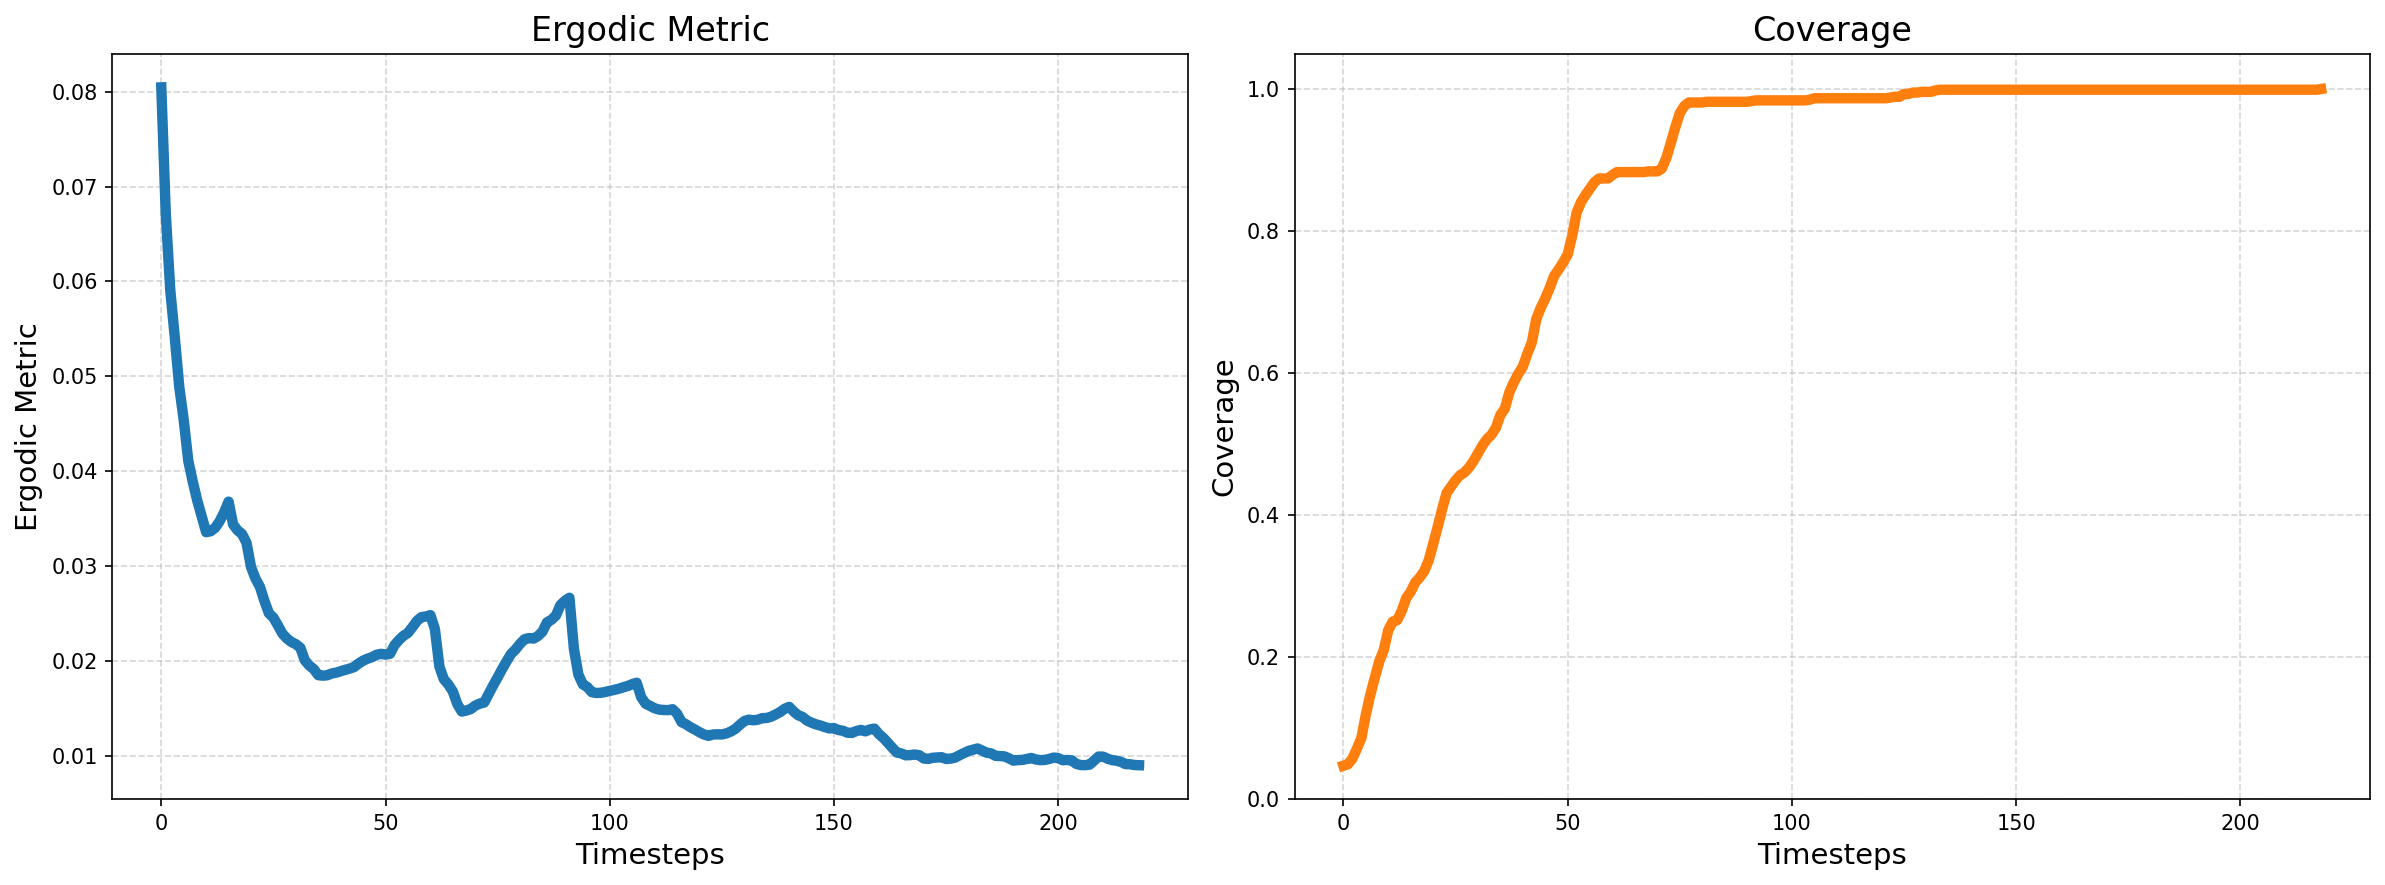

In [13]:
# Plot the ergodic metric and coverage
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

axes[0].plot(erg_log, color='C0', linewidth=5)
axes[0].set_title("Ergodic Metric", fontsize=16)
axes[0].set_xlabel("Timesteps", fontsize=14)
axes[0].set_ylabel("Ergodic Metric", fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(coverage_log, color='C1', linewidth=5)
axes[1].set_title("Coverage", fontsize=16)
axes[1].set_xlabel("Timesteps", fontsize=14)
axes[1].set_ylabel("Coverage", fontsize=14)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# Visualize the trajectory and coverage
@jit
def all_body_to_world(x_traj):
    return vmap(body_to_world)(x_traj)

fp_raw_traj, footprint_traj, w_traj = all_body_to_world(jnp.asarray(x_traj_hist))

fp_raw_traj_np = np.array(fp_raw_traj)
footprint_traj_np = np.array(footprint_traj)
w_traj_np = np.array(w_traj)
x_traj_hist_np = np.array(x_traj_hist)

def body_to_world_np(xt):
    x, y, theta, _, _, _ = xt
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    pts_raw = np.array(rel_pos) @ R.T + np.array([x, y])

    inside = (
        (pts_raw[:, 0] >= 0.0) & (pts_raw[:, 0] <= float(L_list[0])) &
        (pts_raw[:, 1] >= 0.0) & (pts_raw[:, 1] <= float(L_list[1]))
    )
    w = inside.astype(np.float32)

    pts_clip = np.clip(
        pts_raw,
        np.array([0.0, 0.0]),
        np.array(L_list)
    )
    return pts_raw, pts_clip, w

def covered_now_np(x, target_pts_np):
    _, pts_clip, w = body_to_world_np(x)

    dx = target_pts_np[:, None, 0] - pts_clip[None, :, 0]
    dy = target_pts_np[:, None, 1] - pts_clip[None, :, 1]
    d2 = dx * dx + dy * dy
    
    cover_radius = 0.005
    r2 = cover_radius * cover_radius
    valid = (w > 0.5)[None, :]
    hit = (d2 <= r2) & valid
    return np.any(hit, axis=1)

target_pts_np = np.array(target_data[:, :2])

mask_remaining = np.ones(target_pts_np.shape[0], dtype=bool)
pts_list_accum = []

for i in range(x_traj_hist_np.shape[0]):
    covered = covered_now_np(x_traj_hist_np[i], target_pts_np[mask_remaining])
    if covered is not None and covered.any():
        rem_idx = np.where(mask_remaining)[0]
        mask_remaining[rem_idx[covered]] = False

    pts_raw_i, _, _ = body_to_world_np(x_traj_hist_np[i])
    pts_list_accum.append(pts_raw_i)

trail_pts = np.vstack(pts_list_accum)
target_vis = target_pts_np[mask_remaining]

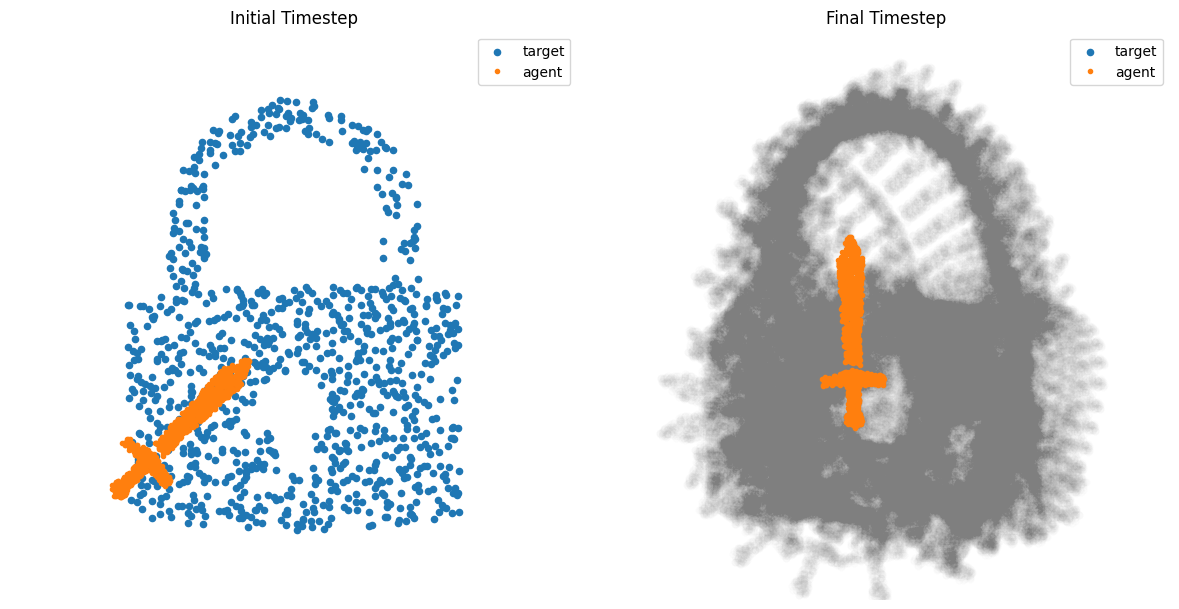

In [15]:
# Plot the initial and final timesteps
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100, tight_layout=True)

axes[0].set_title("Initial Timestep")
axes[0].set_xlim(0.0, 1.0)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_aspect('equal')
axes[0].axis('off')
axes[0].scatter(target_data[:, 0], target_data[:, 1], s=20, alpha=1.0, label="target", color='C0')
axes[0].plot(fp_raw_traj_np[0, :, 0], fp_raw_traj_np[0, :, 1], linestyle='', marker='o', markersize=3, color='C1', alpha=1.0, label='agent')
axes[0].legend()

axes[1].set_title("Final Timestep")
axes[1].set_xlim(0.0, 1.0)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].scatter(target_vis[:, 0], target_vis[:, 1], s=20, alpha=1.0, label="target", color='C0')
axes[1].plot(trail_pts[:, 0], trail_pts[:, 1], linestyle='', marker='o', markersize=5, color='C7', alpha=0.01)
axes[1].plot(fp_raw_traj_np[-1, :, 0], fp_raw_traj_np[-1, :, 1], linestyle='', marker='o', markersize=3, color='C1', alpha=1.0, label='agent')
axes[1].legend()

plt.show()
plt.close()

### Render Video

In [16]:
video_frames = []

mask_remaining = np.ones(target_pts_np.shape[0], dtype=bool)
pts_list_accum = []

for i in tqdm(range(x_traj_hist_np.shape[0]), desc="Rendering video"):
    # Update erased target
    covered = covered_now_np(x_traj_hist_np[i], target_pts_np[mask_remaining])
    if covered is not None and covered.any():
        rem_idx = np.where(mask_remaining)[0]
        mask_remaining[rem_idx[covered]] = False

    target_vis = target_pts_np[mask_remaining]

    # Accumulate agent trail
    pts_raw_i, pts_clip_i, w_i = body_to_world_np(x_traj_hist_np[i])
    pts_list_accum.append(pts_raw_i)
    trail_pts = np.vstack(pts_list_accum)

    # Plot one frame
    fig, ax = plt.subplots(1, 1, figsize=(6.4, 6.4), dpi=150)
    ax.set_title(f"Timestep: {i}")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.scatter(target_vis[:, 0], target_vis[:, 1], s=20, alpha=1.0, color="C0")
    ax.plot(trail_pts[:, 0], trail_pts[:, 1], linestyle="", marker="o", markersize=5, color="C7", alpha=0.01)
    ax.plot(pts_clip_i[w_i > 0.5, 0], pts_clip_i[w_i > 0.5, 1], linestyle="", marker="o", markersize=3, color="C1", alpha=1.0)

    fig.tight_layout(pad=1.0)

    # Convert matplotlib figure to RGB frame
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba(), dtype=np.uint8)[..., :3].copy()
    video_frames.append(frame)

    plt.close(fig)

print(f"Rendered {len(video_frames)} video frames.")

Rendering video:   0%|          | 0/219 [00:00<?, ?it/s]

Rendered 219 video frames.


In [17]:
video_path = f"erasing_mpc_{agent_name}_{target_name}.mp4"

imageio.mimsave(video_path, video_frames, fps=30, codec="libx264", quality=10, macro_block_size=16)
print("Video saved:", video_path)

display(Video(video_path, embed=True, width=512, height=512))

/home/jueun2/miniconda3/envs/jax/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Video saved: erasing_mpc_sword_lock.mp4
